In [55]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from torchvision import transforms
from torchvision.models import resnet50
from torchvision.datasets import ImageFolder

from torch.utils.data import DataLoader
from torch.nn import CrossEntropyLoss
from torch.optim import AdamW


In [56]:
train_counts = Counter(train_folder.targets)
val_counts = Counter(val_folder.targets)
print("ESTADÍSTICAS DEL VOLUMEN DE DATOS")
print(f"Conjunto de ENTRENAMIENTO (Total: {len(train_folder)} imágenes):")
print(f"  - Autos Dañados (00-damage): {train_counts[0]} imágenes")
print(f"  - Autos Sanos (01-whole):    {train_counts[1]} imágenes")
print(f"Conjunto de VALIDACIÓN (Total: {len(val_folder)} imágenes):")
print(f"  - Autos Dañados (00-damage): {val_counts[0]} imágenes")
print(f"  - Autos Sanos (01-whole):    {val_counts[1]} imágenes")

ESTADÍSTICAS DEL VOLUMEN DE DATOS
Conjunto de ENTRENAMIENTO (Total: 1840 imágenes):
  - Autos Dañados (00-damage): 920 imágenes
  - Autos Sanos (01-whole):    920 imágenes
Conjunto de VALIDACIÓN (Total: 460 imágenes):
  - Autos Dañados (00-damage): 230 imágenes
  - Autos Sanos (01-whole):    230 imágenes



Visualizando muestras de ambas clases para el EDA...


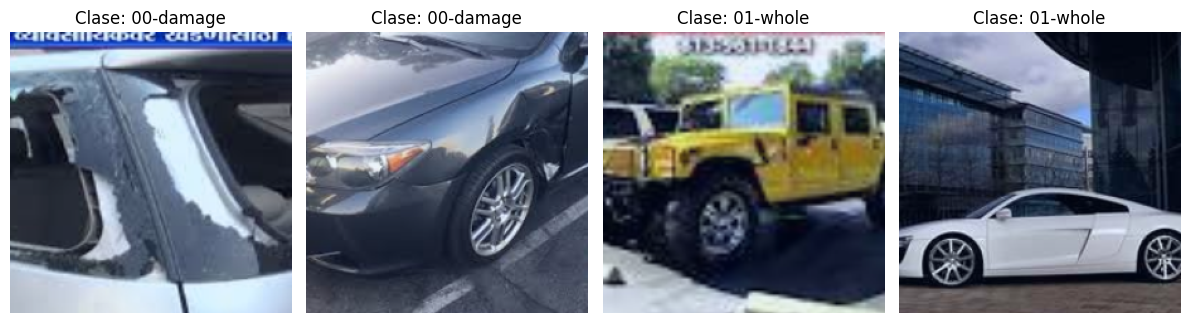

In [57]:
# 2. Visualizar muestras reales balanceadas del dataset (2 dañados y 2 sanos)
plt.figure(figsize=(12, 5))
print("\nVisualizando muestras de ambas clases para el EDA...")

# Encontrar los índices del primer auto dañado (0) y el primer auto sano (1)
indices_dañados = [i for i, label in enumerate(train_folder.targets) if label == 0]
indices_sanos = [i for i, label in enumerate(train_folder.targets) if label == 1]

# Tomamos 2 muestras de cada lista de forma espaciada
muestras_indices = [indices_dañados[0], indices_dañados[50], indices_sanos[0], indices_sanos[50]]

for i, idx in enumerate(muestras_indices):
    img_tensor, label = train_folder[idx]
    
    # Desnormalizar para matplotlib
    img_array = img_tensor.permute(1, 2, 0).numpy()
    img_array = (img_array - img_array.min()) / (img_array.max() - img_array.min())
    
    plt.subplot(1, 4, i + 1)
    plt.imshow(img_array)
    plt.title(f"Clase: {class_names[label]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Analizando dimensiones originales de las imágenes...
 - Resolución promedio: 267x190 píxeles
 - Resolución mínima encontrada: 168x161
 - Resolución máxima encontrada: 313x299

Calculando distribución de canales de color...


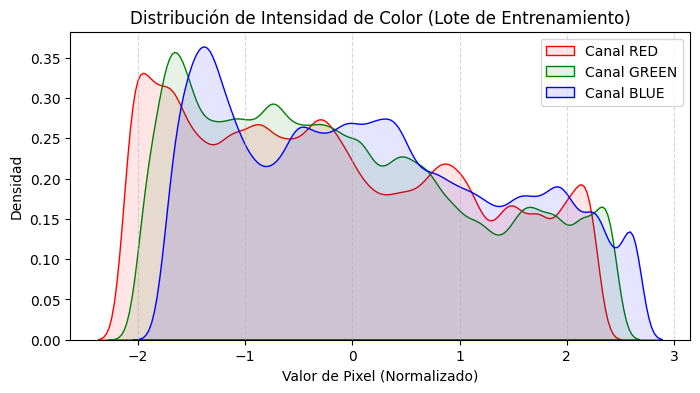

In [ ]:
import numpy as np
from PIL import Image

# Analizo dimensiones originales de las imágenes 
# Cargoo una muestra de rutas crudas directamente desde los archivos
print("Analizando dimensiones originales de las imágenes...")
original_sizes = []

# Tomamos una muestra de las primeras 50 imágenes del set de datos
for path, _ in train_folder.imgs[:50]:
    with Image.open(path) as img:
        original_sizes.append(img.size) # Guarda (Ancho, Alto)

widths, heights = zip(*original_sizes)

print(f" - Resolución promedio: {int(np.mean(widths))}x{int(np.mean(heights))} píxeles")
print(f" - Resolución mínima encontrada: {np.min(widths)}x{np.min(heights)}")
print(f" - Resolución máxima encontrada: {np.max(widths)}x{np.max(heights)}")

# Análisis del histograma de color promedio (Canales R, G, B)
plt.figure(figsize=(8, 4))
colors = ('red', 'green', 'blue')
print("\nCalculando distribución de canales de color...")

#Tomamo un lote de imágenes del loader para ver los canales ya procesados
images_batch, _ = next(iter(train_loader))

for i, color in enumerate(colors):
    # Extraig el canal correspondiente de todo el batch y calculamos su histograma
    channel_data = images_batch[:, i, :, :].numpy().flatten()
    sns.kdeplot(channel_data, color=color, label=f'Canal {color.upper()}', fill=True, alpha=0.1)

plt.title("Distribución de Intensidad de Color (Lote de Entrenamiento)")
plt.xlabel("Valor de Pixel (Normalizado)")
plt.ylabel("Densidad")
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

In [59]:
# GPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo:", device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Dispositivo: cuda
NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [60]:
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(), # <- Aumento de datos
    transforms.RandomRotation(15),     # <- Aumento de datos
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [61]:
# DATASET
train_folder = ImageFolder(
    "./archive/data1a/training",
    transform=transform)

val_folder = ImageFolder(
    "./archive/data1a/validation",
    transform=transform)

print(train_folder.classes)
print(train_folder.class_to_idx)

# DATALOADER
train_loader = DataLoader(
    train_folder,
    batch_size=16,
    shuffle=True)

val_loader = DataLoader(
    val_folder,
    batch_size=16,
    shuffle=False)

model = resnet50(
    weights="IMAGENET1K_V1")

['00-damage', '01-whole']
{'00-damage': 0, '01-whole': 1}


In [62]:
# Congelar toda la red
for param in model.parameters():

    param.requires_grad = False

# Cambiar capa final
model.fc = nn.Sequential(

    nn.Dropout(0.5),

    nn.Linear(
        2048,
        2
    )

)


In [63]:
# Descongelar última parte
for param in model.layer4.parameters():

    param.requires_grad = True

for param in model.fc.parameters():

    param.requires_grad = True


In [64]:
# Mandar a GPU
model = model.to(device)

In [65]:
# Revisar capas entrenables
print("\nCapas entrenables:")

for name,param in model.named_parameters():

    if param.requires_grad:

        print(name)


Capas entrenables:
layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.conv3.weight
layer4.0.bn3.weight
layer4.0.bn3.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
layer4.1.conv3.weight
layer4.1.bn3.weight
layer4.1.bn3.bias
layer4.2.conv1.weight
layer4.2.bn1.weight
layer4.2.bn1.bias
layer4.2.conv2.weight
layer4.2.bn2.weight
layer4.2.bn2.bias
layer4.2.conv3.weight
layer4.2.bn3.weight
layer4.2.bn3.bias
fc.1.weight
fc.1.bias


In [66]:
# FUNCIÓN ENTRENAMIENTO
def training_loop(
        optimizer,
        loss_fn,
        epochs=30,
        patience=6
):
    
    torch.nn.init.kaiming_normal_(model.fc[1].weight)
    if model.fc[1].bias is not None:
        torch.nn.init.zeros_(model.fc[1].bias)

    train_losses=[]
    train_acc=[]
    val_losses=[]
    val_acc=[]

    best_accuracy=0

    patience_count=0

    for epoch in range(epochs):

        print(
            f"\nEpoch {epoch+1}/{epochs}")


       
        # TRAIN       
        model.train()

        total_loss=0
        correct=0
        total=0

        for data,target in train_loader:

            data=data.to(device)
            target=target.to(device)
            optimizer.zero_grad()
            output=model(data)

            loss=loss_fn(
                output,
                target
            )

            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            pred=output.argmax(1)
            
            correct += (
                pred==target
            ).sum().item()

            total += target.size(0)

        train_loss=total_loss/len(train_loader)
        train_accuracy=correct/total
        train_losses.append(train_loss)
        train_acc.append(train_accuracy)

        print(
            f"Train Loss: {train_loss:.4f} | "
            f"Accuracy: {train_accuracy:.4f}")

        
        # VALIDACION   
        model.eval()

        val_loss_total=0
        val_correct=0
        val_total=0

        with torch.no_grad():

            for data,target in val_loader:

                data=data.to(device)
                target=target.to(device)
                output=model(data)

                loss=loss_fn(
                    output,
                    target
                )

                val_loss_total += loss.item()
                pred=output.argmax(1)

                val_correct += (
                    pred==target
                ).sum().item()

                val_total += target.size(0)

        val_loss=val_loss_total/len(val_loader)
        val_accuracy=val_correct/val_total
        val_losses.append(val_loss)
        val_acc.append(val_accuracy)

        print(
            f"Val Loss: {val_loss:.4f} | "
            f"Accuracy: {val_accuracy:.4f}"
        )



        # Guardar mejor modelo
        if val_accuracy > best_accuracy:
            best_accuracy=val_accuracy
            torch.save(
                model.state_dict(),
                "best_damage_model.pth"
            )
            print(
                "Mejor modelo guardado:",
                best_accuracy
            )
            patience_count=0

        else:

            patience_count += 1

            if patience_count >= patience:
                print(
                    "Early stopping"
                )
                break

    return (
        train_losses,
        train_acc,
        val_losses,
        val_acc)


# ENTRENAMIENTO
optimizer = AdamW(

    filter(
        lambda p:p.requires_grad,
        model.parameters()
    ),
    lr=0.0001, weight_decay=0.01)

loss_fn = CrossEntropyLoss()

all_train_loss, all_train_accuracy, all_val_loss, all_val_accuracy = training_loop(

    optimizer,
    loss_fn,
    epochs=30,
    patience=6)



Epoch 1/30
Train Loss: 0.3220 | Accuracy: 0.8696
Val Loss: 0.1805 | Accuracy: 0.9304
Mejor modelo guardado: 0.9304347826086956

Epoch 2/30
Train Loss: 0.0880 | Accuracy: 0.9674
Val Loss: 0.1938 | Accuracy: 0.9304

Epoch 3/30
Train Loss: 0.0442 | Accuracy: 0.9832
Val Loss: 0.2181 | Accuracy: 0.9370
Mejor modelo guardado: 0.9369565217391305

Epoch 4/30
Train Loss: 0.0602 | Accuracy: 0.9777
Val Loss: 0.2470 | Accuracy: 0.9239

Epoch 5/30
Train Loss: 0.0327 | Accuracy: 0.9897
Val Loss: 0.2141 | Accuracy: 0.9457
Mejor modelo guardado: 0.9456521739130435

Epoch 6/30
Train Loss: 0.0172 | Accuracy: 0.9940
Val Loss: 0.2301 | Accuracy: 0.9435

Epoch 7/30
Train Loss: 0.0225 | Accuracy: 0.9940
Val Loss: 0.2589 | Accuracy: 0.9304

Epoch 8/30
Train Loss: 0.0169 | Accuracy: 0.9918
Val Loss: 0.3177 | Accuracy: 0.9109

Epoch 9/30
Train Loss: 0.0160 | Accuracy: 0.9946
Val Loss: 0.1494 | Accuracy: 0.9500
Mejor modelo guardado: 0.95

Epoch 10/30
Train Loss: 0.0396 | Accuracy: 0.9886
Val Loss: 0.4247 | Ac

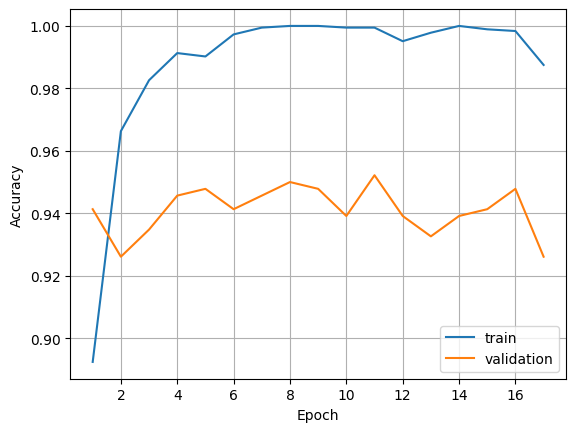

In [46]:
# CARGAR MEJOR MODELO
model.load_state_dict(
    torch.load(
        "best_damage_model.pth"
    )

)
model.eval()

# GRAFICO ACCURACY
sns.lineplot(
    x=range(1,len(all_train_accuracy)+1),
    y=all_train_accuracy,
    label="train")

sns.lineplot(
    x=range(1,len(all_val_accuracy)+1),
    y=all_val_accuracy,
    label="validation")

plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.grid()
plt.show()

In [47]:
# PREDICCION AUTO REAL
img = Image.open(
    r"C:\Users\alons\OneDrive\Desktop\proyecto2\autodañado.jpg"
).convert("RGB")

img_t = transform(img)
batch = img_t.unsqueeze(0).to(device)

with torch.no_grad():
    logits=model(batch)

    probs=F.softmax(
        logits,
        dim=1)

resultado=pd.DataFrame(

    probs.cpu().numpy(),

    columns=[
        "00-damage",
        "01-whole"])
print(resultado)


# Clase final
prediction = probs.argmax(1).item()
print(
    "\nPredicción:",
    train_folder.classes[prediction])

print(
    "Confianza:",
    probs[0][prediction].item())

   00-damage  01-whole
0    0.99924   0.00076

Predicción: 00-damage
Confianza: 0.9992402791976929


              precision    recall  f1-score   support

   00-damage       0.94      0.96      0.95       230
    01-whole       0.96      0.94      0.95       230

    accuracy                           0.95       460
   macro avg       0.95      0.95      0.95       460
weighted avg       0.95      0.95      0.95       460



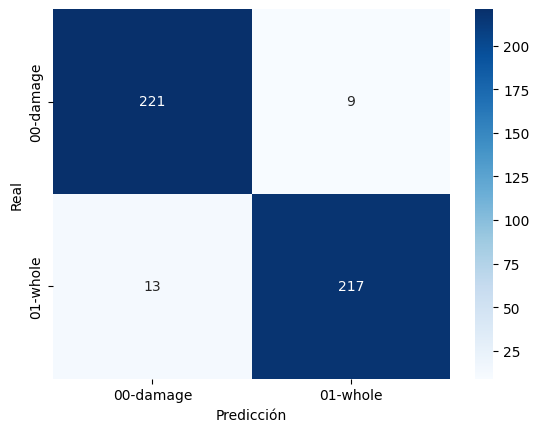

In [48]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in val_loader: # O test_loader si lo separas
        data, target = data.to(device), target.to(device)
        output = model(data)
        preds = output.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

# Imprimir reporte de clasificación (Precision, Recall, F1)
print(classification_report(all_targets, all_preds, target_names=train_folder.classes))

# Graficar Matriz de Confusión
cm = confusion_matrix(all_targets, all_preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_folder.classes, yticklabels=train_folder.classes, cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()